# Performance Analytics of Mutual Funds

### Objective

This notebook computes key performance and risk metrics for all mutual fund schemes using historical NAV data. The analysis includes daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, composite fund scoring, and benchmark comparison against NIFTY 100.

Datasets Used

- 01_fund_master_cleaned.csv
- 02_nav_history_cleaned.csv
- 07_scheme_performance_cleaned.csv
- 10_benchmark_indices_cleaned.csv

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import linregress

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [5]:
DATA_PATH = "../data/processed"
OUTPUT_PATH = "../outputs"

Path(OUTPUT_PATH).mkdir(exist_ok=True)

In [6]:
fund_master = pd.read_csv(f"{DATA_PATH}/01_fund_master_cleaned.csv")

nav = pd.read_csv(f"{DATA_PATH}/02_nav_history_cleaned.csv")

scheme = pd.read_csv(f"{DATA_PATH}/07_scheme_performance_cleaned.csv")

benchmark = pd.read_csv(f"{DATA_PATH}/10_benchmark_indices_cleaned.csv")

In [7]:
print(nav.shape)

print(nav.head())

print(nav.info())

(64320, 4)
         date  amfi_code       nav  daily_return_pct
0  2022-01-03     100016  520.4608               NaN
1  2022-01-04     100016  515.0971         -1.030568
2  2022-01-05     100016  521.7239          1.286515
3  2022-01-06     100016  515.7880         -1.137747
4  2022-01-07     100016  515.1639         -0.120999
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64320 entries, 0 to 64319
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              64320 non-null  object 
 1   amfi_code         64320 non-null  int64  
 2   nav               64320 non-null  float64
 3   daily_return_pct  64280 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 2.0+ MB
None


## Data Cleaning

In [8]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [9]:
nav.isnull().sum()

benchmark.isnull().sum()

date           0
index_name     0
close_value    0
dtype: int64

In [10]:
nav.duplicated().sum()

0

In [11]:
nav.describe()

,date,amfi_code,nav,daily_return_pct
count,64320,64320.000000,64320.000000,64280.000000
mean,2024-03-16 12:00:00,120247.000000,269.530464,0.045120
min,2022-01-03 00:00:00,100016.000000,26.136600,-5.810201
25%,2023-02-08 18:00:00,118632.750000,69.180175,-0.209179
50%,2024-03-16 12:00:00,119551.500000,122.751200,0.000000
75%,2025-04-22 06:00:00,120842.250000,260.171425,0.323272
max,2026-05-29 00:00:00,149324.000000,4268.549700,6.471309
std,NaN,14352.272787,577.144541,0.870595


<Axes: xlabel='amfi_code'>

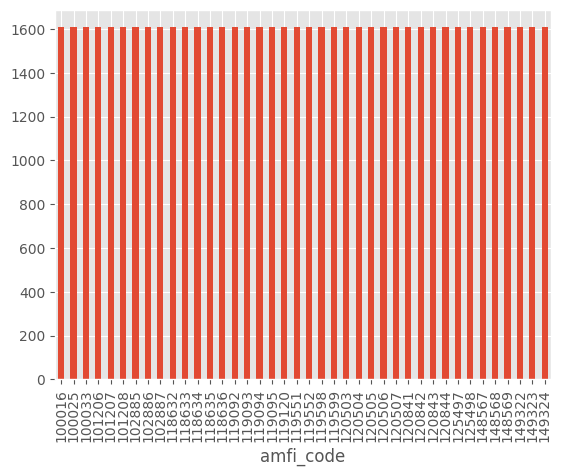

In [12]:
nav.groupby("amfi_code").size().plot(kind="bar")

(array([35074., 11844.,  6372.,  5002.,  1225.,  1819.,   459.,   521.,
          180.,   102.,    57.,    57.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,    36.,   161.,   168.,
          177.,   139.,   176.,   197.,   145.,   161.,   126.,   122.]),
 array([  26.1366   ,  132.1969275,  238.257255 ,  344.3175825,
         450.37791  ,  556.4382375,  662.498565 ,  768.5588925,
         874.61922  ,  980.6795475, 1086.739875 , 1192.8002025,
        1298.86053  , 1404.9208575, 1510.981185 , 1617.0415125,
        1723.10184  , 1829.1621675, 1935.222495 , 2041.2828225,
        2147.34315  , 2253.4034775, 2359.463805 , 2465.5241325,
        2571.58446  , 2677.6447875, 2783.705115 , 2889.7654425,
        2995.82577  , 3101.8860975, 3207.946425 , 3314.0067525,
        3420.06708  , 3526.1274075, 3632.187735 , 3738.2480625,
        3844.30839  , 3950.3687175, 4056.429045 , 4162.4893725

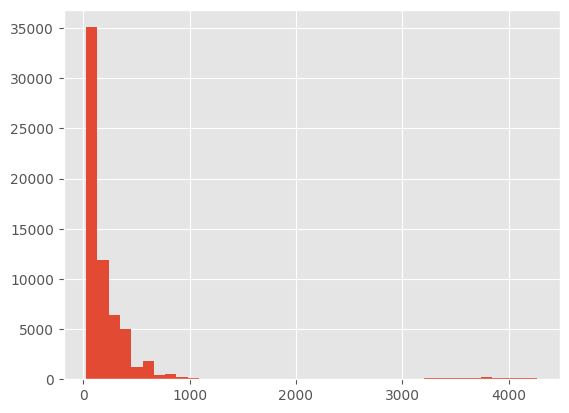

In [13]:
plt.hist(nav["nav"], bins=40)

# Daily Return Calculation

Daily return measures the percentage change in Net Asset Value (NAV) from one trading day to the next.

Formula:

Daily Return = (NAV_t / NAV_(t-1)) - 1

These returns are the foundation for all subsequent risk and performance metrics.

In [14]:
returns = nav.copy()

In [15]:
returns["daily_return"] = (
    returns
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [16]:
returns.head(10)

,date,amfi_code,nav,daily_return_pct,daily_return
0,2022-01-03,100016,520.4608,NaN,NaN
1,2022-01-04,100016,515.0971,-1.030568,-0.010306
2,2022-01-05,100016,521.7239,1.286515,0.012865
3,2022-01-06,100016,515.7880,-1.137747,-0.011377
4,2022-01-07,100016,515.1639,-0.120999,-0.001210
5,2022-01-08,100016,515.1639,0.000000,0.000000
6,2022-01-09,100016,515.1639,0.000000,0.000000
7,2022-01-10,100016,510.7136,-0.863861,-0.008639
8,2022-01-11,100016,513.5542,0.556202,0.005562
9,2022-01-12,100016,512.3195,-0.240423,-0.002404


In [17]:
returns = returns.dropna(subset=["daily_return"])

In [18]:
returns["daily_return"].describe()

count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

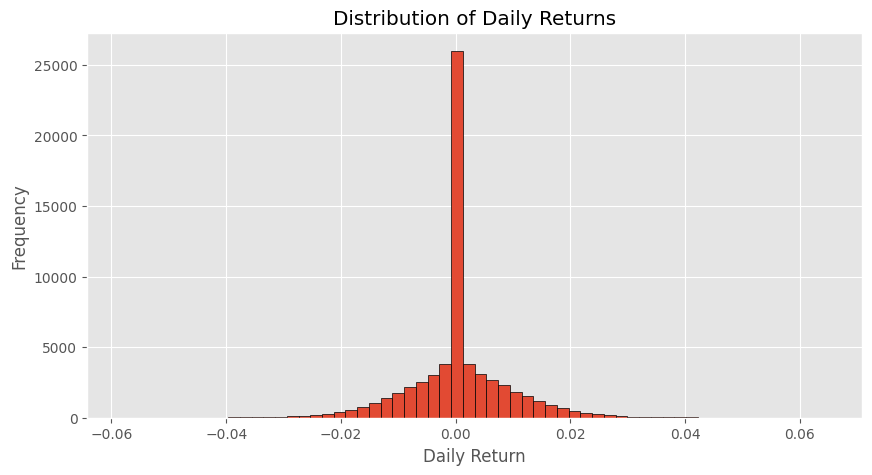

In [19]:
plt.figure(figsize=(10,5))

plt.hist(
    returns["daily_return"],
    bins=60,
    edgecolor="black"
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [20]:
returns.to_csv(
    f"{OUTPUT_PATH}/returns_computed.csv",
    index=False
)

# CAGR

Compound Annual Growth Rate measures the annualized growth of an investment over a specified period.

Formula:

CAGR = (Ending NAV / Starting NAV)^(1/Years) - 1

In [21]:
def calculate_cagr(group, years):
    
    end_date = group["date"].max()
    
    start_date = end_date - pd.DateOffset(years=years)

    period = group[group["date"] >= start_date]

    if len(period) < 2:
        return np.nan

    start_nav = period.iloc[0]["nav"]

    end_nav = period.iloc[-1]["nav"]

    return (end_nav/start_nav)**(1/years)-1

In [22]:
cagr_list = []

for fund in returns["amfi_code"].unique():

    temp = nav[nav["amfi_code"]==fund].sort_values("date")

    cagr_list.append({

        "amfi_code": fund,

        "CAGR_1Y": calculate_cagr(temp,1),

        "CAGR_3Y": calculate_cagr(temp,3),

        "CAGR_5Y": calculate_cagr(temp,5)

    })

In [23]:
cagr_df = pd.DataFrame(cagr_list)

In [24]:
cagr_df = cagr_df.merge(

    fund_master[["amfi_code","scheme_name"]],

    on="amfi_code"

)

In [25]:
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth


In [26]:
cagr_df.to_csv(

    f"{OUTPUT_PATH}/cagr_report.csv",

    index=False

)

# Sharpe Ratio

Sharpe Ratio measures return earned per unit of total risk.

Formula:

Sharpe =
(mean return − risk free rate)
/ standard deviation
× √252

Risk-free rate = 6.5%

In [27]:
RF = 0.065

daily_rf = RF/252

In [28]:
sharpe = []

for fund in returns["amfi_code"].unique():

    temp = returns[
        returns["amfi_code"]==fund
    ]

    mean_return = temp["daily_return"].mean()

    std_return = temp["daily_return"].std()

    ratio = (
        (mean_return-daily_rf)
        /
        std_return
    )*np.sqrt(252)

    sharpe.append({

        "amfi_code":fund,

        "Sharpe Ratio":ratio

    })

In [29]:
sharpe_df = pd.DataFrame(sharpe)

In [30]:
sharpe_df = sharpe_df.merge(

    fund_master[["amfi_code","scheme_name"]],

    on="amfi_code"

)

In [31]:
sharpe_df["Rank"] = (

    sharpe_df["Sharpe Ratio"]

    .rank(

        ascending=False

    )

)

In [33]:
sharpe_df.to_csv(

    f"{OUTPUT_PATH}/sharpe_values.csv",

    index=False

)

# Sortino Ratio

Unlike Sharpe Ratio, Sortino Ratio penalizes only downside volatility.

Only negative return days are considered risk.

In [34]:
sortino = []

for fund in returns["amfi_code"].unique():

    temp = returns[
        returns["amfi_code"]==fund
    ]

    downside = temp[
        temp["daily_return"]<0
    ]["daily_return"]

    downside_std = downside.std()

    mean_return = temp["daily_return"].mean()

    ratio = (

        (mean_return-daily_rf)

        /

        downside_std

    )*np.sqrt(252)

    sortino.append({

        "amfi_code":fund,

        "Sortino Ratio":ratio

    })

In [35]:
sortino_df = pd.DataFrame(sortino)

In [36]:
sortino_df = sortino_df.merge(

    fund_master[["amfi_code","scheme_name"]],

    on="amfi_code"

)

In [37]:
sortino_df["Rank"] = (

    sortino_df["Sortino Ratio"]

    .rank(

        ascending=False

    )

)

In [38]:
sortino_df.to_csv(

    f"{OUTPUT_PATH}/sortino_values.csv",

    index=False

)

In [39]:
print(returns.shape)
print(cagr_df.shape)
print(sharpe_df.shape)
print(sortino_df.shape)

(64280, 5)
(40, 5)
(40, 4)
(40, 4)


# Alpha and Beta Analysis

Alpha and Beta are calculated using linear regression between the daily returns of each mutual fund and the NIFTY 100 benchmark.

- Beta measures the sensitivity of the fund to market movements.
- Alpha measures the excess return generated beyond what Beta explains.

Method Used:
scipy.stats.linregress()

Annualized Alpha = Daily Alpha × 252

In [110]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [111]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [112]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [113]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100 = nifty100.dropna()

In [114]:
alpha_beta = []

In [115]:
for fund in returns["amfi_code"].unique():

    fund_return = returns[
        returns["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = fund_return.merge(
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )
    # print(fund_return["date"].dtype)
    # print(nifty100["date"].dtype)

    if merged.empty:
        print(f"No matching dates for fund {fund}")
        continue

    slope, intercept, r, p, stderr = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append({

        "amfi_code": fund,

        "Alpha": intercept * 252,

        "Beta": slope

    })

In [116]:
alpha_beta_df = pd.DataFrame(alpha_beta)

In [117]:
alpha_beta_df = alpha_beta_df.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code"

)

In [118]:
alpha_beta_df.head()

,amfi_code,Alpha,Beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [119]:
alpha_beta_df.to_csv(
    f"{OUTPUT_PATH}/alpha_beta.csv",
    index=False
)

# Maximum Drawdown

Maximum Drawdown represents the maximum decline from a historical peak NAV before a new peak is reached.

Formula

Drawdown = NAV / Running Maximum - 1

The minimum drawdown value is the Maximum Drawdown.

In [120]:
drawdown_list = []

In [121]:
for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values("date")

    temp["Running_Max"] = temp["nav"].cummax()

    temp["Drawdown"] = (
        temp["nav"]
        /
        temp["Running_Max"]
    ) - 1
    worst_idx = temp["Drawdown"].idxmin()

    worst_row = temp.loc[worst_idx]
    peak_idx = temp.loc[:worst_idx, "nav"].idxmax()

    peak_date = temp.loc[peak_idx, "date"]
    drawdown_list.append({

        "amfi_code": fund,

        "Peak Date": peak_date,

        "Worst Date": worst_row["date"],

        "Maximum Drawdown": worst_row["Drawdown"]

    })


In [122]:
drawdown_df = pd.DataFrame(drawdown_list)

In [123]:
drawdown_df = drawdown_df.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code"

)

In [124]:
drawdown_df.to_csv(

    f"{OUTPUT_PATH}/max_drawdown.csv",

    index=False

)

In [125]:
performance = cagr_df.merge(
    sharpe_df[
        ["amfi_code", "Sharpe Ratio"]
    ],
    on="amfi_code"
)

In [126]:
performance = performance.merge(

    sortino_df[
        ["amfi_code", "Sortino Ratio"]
    ],

    on="amfi_code"
)

performance = performance.merge(

    alpha_beta_df[
        ["amfi_code", "Alpha", "Beta"]
    ],

    on="amfi_code"
)

performance = performance.merge(

    drawdown_df[
        ["amfi_code", "Maximum Drawdown"]
    ],

    on="amfi_code"
)

performance = performance.merge(

    fund_master[
        ["amfi_code", "expense_ratio_pct"]
    ],

    on="amfi_code"
)

In [127]:
performance.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name,Sharpe Ratio,Sortino Ratio,Alpha,Beta,Maximum Drawdown,expense_ratio_pct
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth,-0.321019,-0.472822,0.037476,-0.058268,-0.247344,1.55
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth,-1.039941,-1.461220,0.042818,0.001158,-0.043083,0.56
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.808268,1.144216,0.271954,0.005104,-0.162172,1.38
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth,0.717409,1.063909,0.213998,0.021086,-0.112916,1.60
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth,0.052618,0.075668,0.108971,-0.065289,-0.354469,1.53


# Composite Fund Scorecard

The final score is calculated using weighted ranks.

Weight Distribution

30%  → 3-Year CAGR

25%  → Sharpe Ratio

20%  → Alpha

15%  → Expense Ratio (Lower is Better)

10%  → Maximum Drawdown (Lower is Better)

In [128]:
performance["Return Rank"] = performance[
    "CAGR_3Y"
].rank(
    ascending=False
)

In [129]:
performance["Sharpe Rank"] = performance[
    "Sharpe Ratio"
].rank(
    ascending=False
)

In [130]:
performance["Alpha Rank"] = performance[
    "Alpha"
].rank(
    ascending=False
)

In [131]:
performance["Expense Rank"] = performance[
    "expense_ratio_pct"
].rank()

In [132]:
performance["Drawdown Rank"] = performance[
    "Maximum Drawdown"
].rank(
    ascending=False
)

In [133]:
def rank_to_score(rank_series):
    n = len(rank_series)
    return ((n - rank_series) / (n - 1)) * 100

In [134]:
performance["Return Score"] = rank_to_score(performance["Return Rank"])
performance["Sharpe Score"] = rank_to_score(performance["Sharpe Rank"])
performance["Alpha Score"] = rank_to_score(performance["Alpha Rank"])
performance["Expense Score"] = rank_to_score(performance["Expense Rank"])
performance["Drawdown Score"] = rank_to_score(performance["Drawdown Rank"])

In [135]:
performance["Fund Score"] = (

    0.30 * performance["Return Score"]

    + 0.25 * performance["Sharpe Score"]

    + 0.20 * performance["Alpha Score"]

    + 0.15 * performance["Expense Score"]

    + 0.10 * performance["Drawdown Score"]

)

In [136]:
performance = performance.sort_values(
    "Fund Score",
    ascending=False
)

performance["Overall Rank"] = range(
    1,
    len(performance) + 1
)

In [137]:
performance[
    [
        "Overall Rank",
        "scheme_name",
        "Fund Score"
    ]
].head(10)

,Overall Rank,scheme_name,Fund Score
34,1,Mirae Asset Large Cap Fund - Regular - Growth,85.897436
25,2,ICICI Pru Midcap Fund - Regular - Growth,82.435897
30,3,Kotak Flexicap Fund - Regular - Growth,81.538462
2,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.256410
24,5,ICICI Pru Bluechip Fund - Direct - Growth,78.846154
16,6,Axis Midcap Fund - Regular - Growth,77.692308
19,7,SBI Bluechip Fund - Regular Plan - Growth,73.525641
36,8,Mirae Asset Tax Saver Fund - Regular - Growth,73.012821
21,9,SBI Small Cap Fund - Regular Plan - Growth,67.179487
3,10,ABSL Frontline Equity Fund - Regular - Growth,66.730769


In [138]:
performance.to_csv(

    f"{OUTPUT_PATH}/fund_scorecard.csv",

    index=False

)

In [139]:
print(alpha_beta_df.shape)
print(drawdown_df.shape)
print(performance.shape)

(40, 4)
(40, 5)
(40, 23)


# Benchmark Comparison

The top five ranked mutual funds are compared against NIFTY 50 and NIFTY 100 over the most recent three-year period.

To ensure a fair comparison, all series are normalized to a base value of 100.

In [141]:
top5 = performance.nsmallest(5, "Overall Rank")["amfi_code"].tolist()

In [142]:
end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

nav_3yr = nav[nav["date"] >= start_date].copy()

benchmark_3yr = benchmark[
    benchmark["date"] >= start_date
].copy()

In [143]:
def normalize(series):
    return (series / series.iloc[0]) * 100

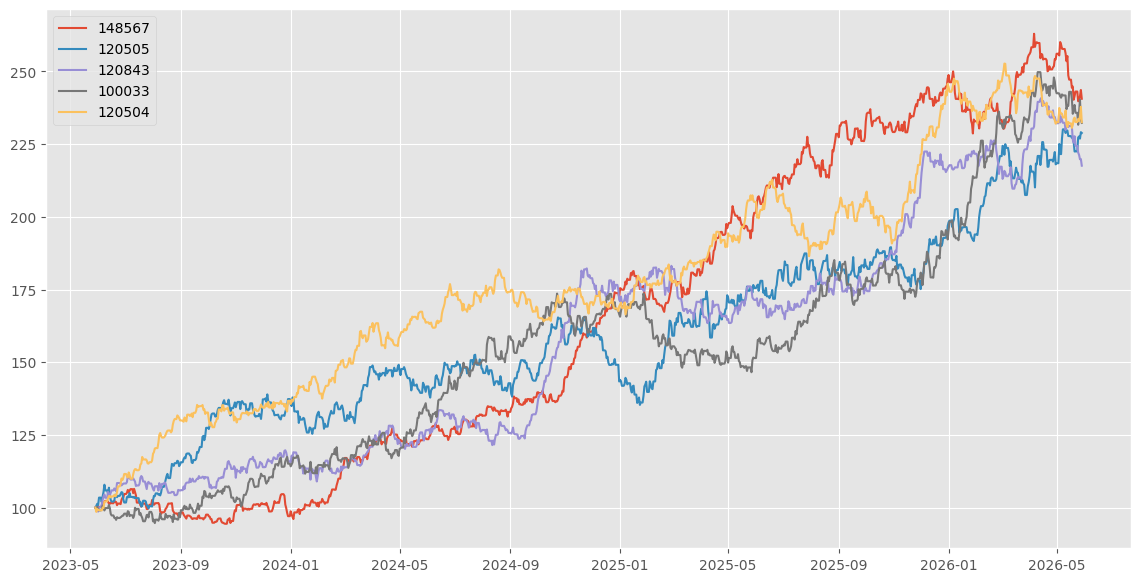

In [145]:
plt.figure(figsize=(14,7))

for fund in top5:

    temp = nav_3yr[
        nav_3yr["amfi_code"] == fund
    ].sort_values("date")

    plt.plot(
        temp["date"],
        normalize(temp["nav"]),
        label=fund
    )

    plt.legend()

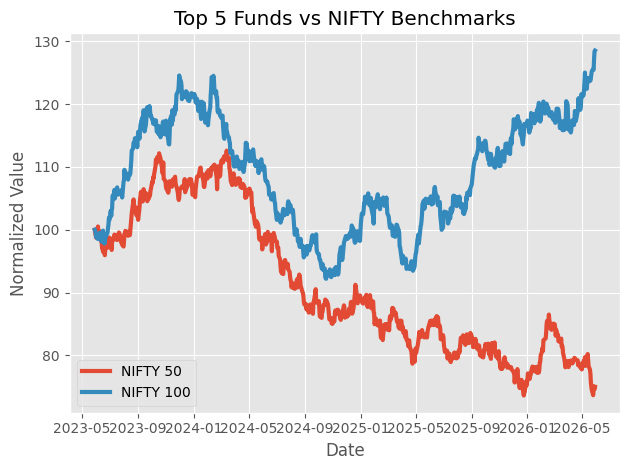

In [152]:
nifty50 = benchmark_3yr[
    benchmark_3yr["index_name"]=="NIFTY50"
].sort_values("date")

plt.plot(
    nifty50["date"],
    normalize(nifty50["close_value"]),
    linewidth=3,
    label="NIFTY 50"
)

nifty100 = benchmark_3yr[
    benchmark_3yr["index_name"]=="NIFTY100"
].sort_values("date")

plt.plot(
    nifty100["date"],
    normalize(nifty100["close_value"]),
    linewidth=3,
    label="NIFTY 100"
)

plt.title(
    "Top 5 Funds vs NIFTY Benchmarks"
)

plt.xlabel("Date")

plt.ylabel("Normalized Value")

plt.legend()

plt.grid(True)

plt.tight_layout()

In [153]:
plt.savefig(

    f"{OUTPUT_PATH}/benchmark_comparison.png",

    dpi=300

)

plt.show()

<Figure size 640x480 with 0 Axes>

# Tracking Error

Tracking Error measures how closely a mutual fund follows its benchmark.

Formula

Tracking Error

=

Std(Fund Return − Benchmark Return)

×

√252

In [154]:
tracking = []

In [157]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [158]:
for fund in top5:

    fund_return = returns[
        returns["amfi_code"]==fund
    ][["date","daily_return"]]

    merged = fund_return.merge(

        nifty100[
            ["date","benchmark_return"]
        ],

        on="date"

    )

    tracking_error = (

        (merged["daily_return"]

        -

        merged["benchmark_return"])

        .std()

    )*np.sqrt(252)

    tracking.append({

        "amfi_code":fund,

        "Tracking Error":tracking_error

    })

In [159]:
tracking_df = pd.DataFrame(tracking)

In [160]:
tracking_df = tracking_df.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code"

)

In [161]:
tracking_df

,amfi_code,Tracking Error,scheme_name
0,148567,0.187974,Mirae Asset Large Cap Fund - Regular - Growth
1,120505,0.232661,ICICI Pru Midcap Fund - Regular - Growth
2,120843,0.206540,Kotak Flexicap Fund - Regular - Growth
3,100033,0.224976,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,120504,0.187299,ICICI Pru Bluechip Fund - Direct - Growth


# Summary

This notebook successfully computed the following metrics for all mutual fund schemes:

- Daily Returns
- CAGR (1-Year, 3-Year, 5-Year*)
- Sharpe Ratio
- Sortino Ratio
- Alpha
- Beta
- Maximum Drawdown
- Composite Fund Score
- Benchmark Comparison
- Tracking Error

*5-Year CAGR was unavailable due to insufficient historical NAV data.

In [163]:
import os

for file in sorted(os.listdir(OUTPUT_PATH)):
    print(file)

alpha_beta.csv
benchmark_comparison.png
cagr_report.csv
fund_scorecard.csv
max_drawdown.csv
returns_computed.csv
sharpe_values.csv
sortino_values.csv
